# Advanced Optical Character Recognition (OCR) Engine
### Internship Project - InternGrow

## 1. Import Required Libraries

In this section, we import the required libraries for loading the dataset, visualizing images, building the CNN model, and evaluating its performance.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense # type: ignore

## 2. Load the Dataset

The MNIST handwritten digit dataset is loaded from OpenML. It contains 70,000 grayscale images of handwritten digits from 0 to 9.

In [8]:
mnist = fetch_openml("mnist_784")

## 3. Separate Features and Labels

The dataset is divided into input features (images) and target labels (digits).

In [28]:
x = mnist["data"]
y = mnist["target"]

## 4. Explore the Dataset

In this step, we examine the dataset by checking its shape, data types, and a few sample records. This helps us understand the structure of the dataset before preprocessing.

In [10]:
print("Shape of Images :", x.shape)
print("Shape of Labels :", y.shape)

Shape of Images : (70000, 784)
Shape of Labels : (70000,)


In [11]:
x.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
y.head()

0    5
1    0
2    4
3    1
4    9
Name: class, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

## 5. Check Missing Values

The dataset is checked for missing values to ensure data quality before training the model.

In [13]:
print(x.isnull().sum())
print(y.isnull().sum())

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 784, dtype: int64
0


## 6. Check Data Types

The data types of the features and labels are checked.

In [14]:
print(x.dtypes)
print(y.dtype)

pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
pixel5      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 784, dtype: object
category


## 7. Display a Sample Image

A sample handwritten digit image is displayed along with its corresponding label.

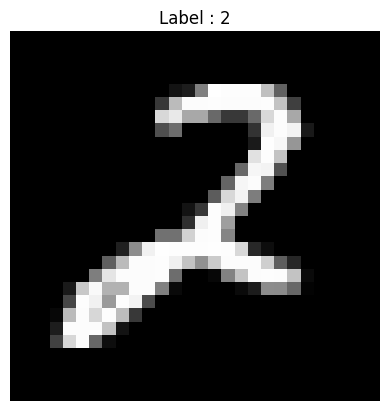

label 2


In [16]:
some_digit = x.iloc[36001]

some_digit_image = some_digit.values.reshape(28, 28)

plt.imshow(some_digit_image, cmap="gray")
plt.title(f"Label : {y.iloc[36001]}")
plt.axis("off")
plt.show()
print("label",y[36001])

## 8. Normalize the Images

The pixel values are normalized from the range 0–255 to 0–1. This helps the CNN model train faster and improves its performance.

In [29]:
x = x / 255.0

## 9. Reshape the Images

The flattened images are reshaped into 28 × 28 grayscale images because CNN models require image data in two-dimensional format.

In [30]:
x = x.values.reshape(-1, 28, 28, 1)

In [31]:
print(x.min())
print(x.max())

0.0
1.0


## 10. Convert Labels

The target labels are converted from string format to integer format because the CNN model requires numerical class labels for training.

In [33]:
y = y.astype(int)

print(y.dtype)

int64


## 11. Split the Dataset

The dataset is divided into training and testing sets. The first 60,000 images are used for training, while the remaining 10,000 images are used for testing the CNN model.

In [34]:
x_train = x[:60000]
x_test = x[60000:]

y_train = y[:60000]
y_test = y[60000:]

In [36]:
print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (60000, 28, 28, 1)
Testing Images  : (10000, 28, 28, 1)
Training Labels : (60000,)
Testing Labels  : (10000,)


## 12. Build the CNN Model

A Convolutional Neural Network (CNN) is created using Keras Sequential API. The model consists of convolution, pooling, flatten, and dense layers to extract image features and classify handwritten digits.

In [37]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))

model.add(Dense(10, activation="softmax"))

c:\Users\TECH CLUB\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 13. Compile the CNN Model

The CNN model is compiled by specifying the optimizer, loss function, and evaluation metric. This step prepares the model for training.

In [38]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 14. Train the CNN Model

The CNN model is trained using the training dataset for multiple epochs. During training, the model learns patterns from handwritten digit images and its performance is validated using the test dataset.

In [39]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9544 - loss: 0.1529 - val_accuracy: 0.9782 - val_loss: 0.0672
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9846 - loss: 0.0515 - val_accuracy: 0.9855 - val_loss: 0.0444
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9900 - loss: 0.0331 - val_accuracy: 0.9839 - val_loss: 0.0488
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9926 - loss: 0.0215 - val_accuracy: 0.9879 - val_loss: 0.0409
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9951 - loss: 0.0150 - val_accuracy: 0.9848 - val_loss: 0.0470


## 15. Evaluate the CNN Model

The trained CNN model is evaluated on the test dataset to measure its overall loss and classification accuracy.

In [40]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9848 - loss: 0.0470
Test Loss : 0.04697954282164574
Test Accuracy : 0.9847999811172485


## 16. Visualize a Sample Prediction

A sample image from the test dataset is displayed along with its predicted label and actual label to verify the model's prediction visually.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


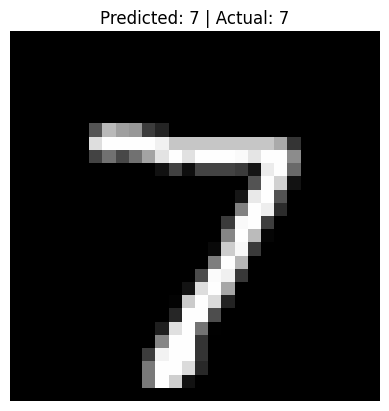

In [41]:
prediction = model.predict(x_test)

predicted_label = np.argmax(prediction[0])

plt.imshow(x_test[0].reshape(28,28), cmap="gray")
plt.title(f"Predicted: {predicted_label} | Actual: {y_test.iloc[0]}")
plt.axis("off")
plt.show()